In [1]:
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 1.4.5


In [ ]:
# from qiskit_ibm_runtime import QiskitRuntimeService

# service = QiskitRuntimeService(name="qgss-2025")
# service.saved_accounts()

d:\MyPrograms\miniconda\envs\qiskit\lib\site-packages\qiskit_ibm_runtime\api\auth.py:67: UserWarning: Unable to retrieve IBM Cloud access token. API Key will be used instead. Error: Cannot log in to the account because it is blocked., Status code: 400
  warnings.warn(
qiskit_runtime_service._discover_backends_from_instance:WARNING:2025-11-27 12:28:45,080: Invalid instance crn:v1:bluemix:public:quantum-computing:us-east:a/41b8ca65ee7f46799ee46a27b8d24ebd:ac605fda-c1f5-4a59-8c3e-8a74c6e7abcd::


{'qgss-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'SdLPpLQVGu6qIZFCVHM_NlXgLclPl6ChHutUjeeZcXxq',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/41b8ca65ee7f46799ee46a27b8d24ebd:ac605fda-c1f5-4a59-8c3e-8a74c6e7abcd::',
  'verify': True,
  'private_endpoint': False}}

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import io
from PIL import Image
import random

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler
from qiskit.result import marginal_distribution
from qiskit.quantum_info import Statevector, Pauli, Operator, SparsePauliOp

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

In [ ]:
def client_qkd_circuit(bit: bool, basis: bool) -> QuantumCircuit:
    """
    Client initializes QKD circuit
    
    Args:
        bit (bool): The bit to be sent (0 or 1).
        basis (bool): The basis to be used (0 for Z-basis, 1 for X-basis).
    
    Returns:
        QuantumCircuit: The quantum circuit for the QKD protocol.
    """
    qc = QuantumCircuit(1, 1, name='qkd_circuit_{bit}_{basis}')
    
    if basis == 0:  # Z-basis
        if bit == 1:
            qc.x(0)  # Prepare |1>
    else: # X-basis
        if bit == 1:
            qc.x(0) # Prepare |1>
        qc.h(0)  # Prepare |+/->
    
    qc.barrier()

    return qc

Circuit 0: (0, 0):


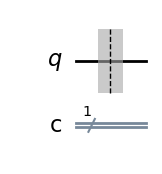



Circuit 1: (0, 1):


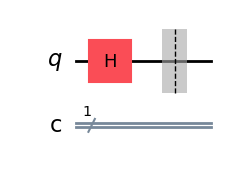



Circuit 2: (1, 0):


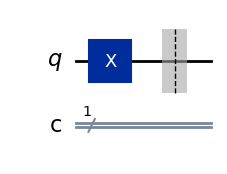



Circuit 3: (1, 1):


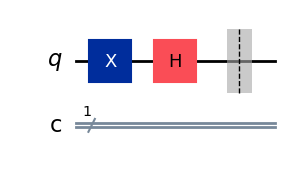

In [5]:
circuits = []
input_pairs = [(bit, basis) for bit in [0, 1] for basis in [0, 1]]
for bit, basis in input_pairs:
    qc = client_qkd_circuit(bit, basis)
    circuits.append(qc)

for i, pair in enumerate(input_pairs):
    print(f"Circuit {i}: {pair}:")
    display(circuits[i].draw("mpl"))
    print("\n")

In [6]:
def server_qkd_circuit(qc: QuantumCircuit, basis: bool) -> QuantumCircuit:
    """
    Create a quantum circuit for the server's response in QKD.
    
    Args:
        qc (QuantumCircuit): The quantum circuit from the client.
        basis (bool): The basis to be used (0 for Z-basis, 1 for X-basis).
    
    Returns:
        QuantumCircuit: The quantum circuit for the server's response.
    """
    if basis == 1:
        qc.h(0)  # Apply Hadamard gate if X-basis is used
        
    qc.measure(0, 0)

    return qc
    

Circuit 0: (0, 0, 0):


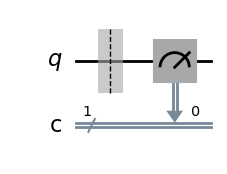



Circuit 1: (0, 0, 1):


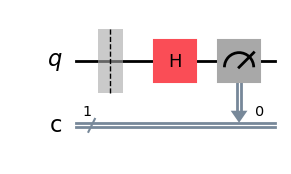



Circuit 2: (0, 1, 0):


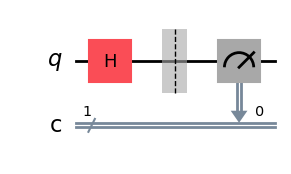



Circuit 3: (0, 1, 1):


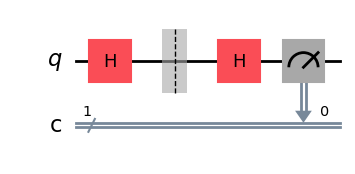



Circuit 4: (1, 0, 0):


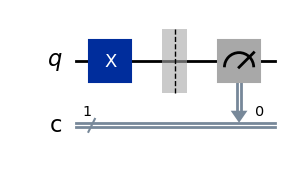



Circuit 5: (1, 0, 1):


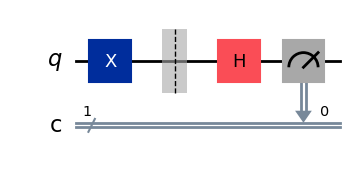



Circuit 6: (1, 1, 0):


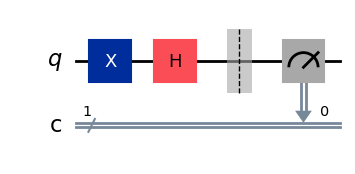



Circuit 7: (1, 1, 1):


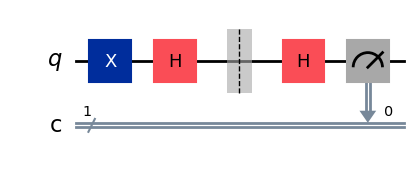

In [7]:
circuits = []
input_pairs = [(bit, basis_alice, basis_bob) for bit in [0, 1] for basis_alice in [0, 1] for basis_bob in [0, 1]]
for bit, basis_alice, basis_bob in input_pairs:
    qc = client_qkd_circuit(bit, basis_alice)
    qc = server_qkd_circuit(qc, basis_bob)
    circuits.append(qc)

for i, pair in enumerate(input_pairs):
    print(f"Circuit {i}: {pair}:")
    display(circuits[i].draw("mpl"))
    print("\n")

In [ ]:
n = 100
alice_bases = np.random.randint(2, size=n)
bob_bases = np.random.randint(2, size=n)

initial_key = np.random.randint(2, size=n)

circuits = []
results = []
for bit, basis_alice, basis_bob in zip(initial_key, alice_bases, bob_bases):
    qc = client_qkd_circuit(bit, basis_alice)
    qc = server_qkd_circuit(qc, basis_bob)
    circuits.append(qc)

for circuit in circuits:
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

    isa_qc = pm.run([circuit])
    sampler = Sampler(mode=backend)
    job = sampler.run(isa_qc, shots=1)
    result = job.result()

    bitarray = result[0].data.c
    bitstring = bitarray.get_bitstrings()[0]

    results.append(bitstring)
    

In [22]:
print("Measured bit:", results)

Measured bit: ['1', '0', '0', '1', '1', '1', '0', '0', '1', '0', '0', '1', '1', '1', '0', '0', '1', '1', '0', '0', '0', '1', '0', '0', '0', '0', '0', '1', '1', '0', '1', '1', '1', '1', '1', '0', '1', '1', '1', '0', '0', '1', '0', '0', '1', '1', '0', '1', '0', '0', '0', '0', '1', '0', '0', '0', '0', '1', '1', '1', '0', '1', '0', '1', '1', '0', '1', '1', '1', '0', '0', '1', '1', '0', '1', '0', '1', '0', '0', '1', '0', '0', '1', '1', '0', '0', '1', '0', '0', '1', '1', '0', '1', '1', '1', '1', '0', '1', '0', '0']


In [25]:
print("initial_key:", initial_key)
print("alice_bases:", alice_bases)
print("bob_bases:", bob_bases)

initial_key: [1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1
 1 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 0
 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 1 0 0 1 1 0 0]
alice_bases: [0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1
 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 0 0 1 0
 0 0 1 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0 0 1 1 1]
bob_bases: [1 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0
 1 0 0 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 0 1 0 1 0 1 0
 0 1 1 0 0 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 0 0]


In [ ]:
# Only keep bits where Alice's and Bob's bases match
sifted_key_result = [int(results[i]) for i in range(n) if alice_bases[i] == bob_bases[i]]
sifted_key_indexes = [i for i in range(n) if alice_bases[i] == bob_bases[i]]
print("Sifted key:", sifted_key_result)

Sifted key: [0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1]


In [35]:
# Verify that the sifted key matches the initial key at the corresponding indexes
sifted_key_initial = [int(initial_key[i]) for i in sifted_key_indexes]
print("Sifted key from initial key:", sifted_key_initial)

if sifted_key_result != sifted_key_initial:
    print("Error: Sifted keys do not match!")
else:
    print("Success: Sifted keys match!")

print("Key length before sifting:", n)
print("Key length after sifting:", len(sifted_key_result))

Sifted key from initial key: [0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Success: Sifted keys match!
Key length before sifting: 100
Key length after sifting: 49
